# Full pipeline for preprosessing, labeling and segmenting a test file set, for 6 sensors

The M.Sc. spring 2026 edition, though this is heavily based on the code from the specialization project conducted in the fall of 2026, which again is heavily derived off of Maria's masters thesis: https://nva.sikt.no/registration/019aaa5d3e02-1f393658-c1a9-4f74-96a3-c428dc10c170

### Imports

In [ ]:

from pre_processing.labeling import detect_spikes, init_label, plot_signal_peaks, extract_activity_windows, apply_corrected_labels, extract_pressure_data, remove_idle, sort_push_pull
from pre_processing.fiks_time_muse import make_df, check_samples, fix_time_muse_hz
from pre_processing.clean_mitch_timestamps import remove_end_duplicates, add_ReconstructedTime
from pre_processing.filter_sensor_data import median_filter_medfilt
from pre_processing.segment_repetition_vol2 import plot_activity_accelerations_peaks_and_magnitude, get_start_stop_times_from_peaks, assign_rep_ids
from plotting.plot_sensor_signals import plot_all_sensors, plot_fsr, plot_single_imu
from utils import get_imu_cols, get_fsr_cols

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Define path to raw sensor files and output directory (same directory as test files is convention)

First, define where data files exist by modifying base_dir and participant_dir_name. Use standardized naming to make file retrieval easier! 

In [ ]:
base_dir = Path(r"C:\Users\Bruker\Data_msc26_prelim")
participant_dir_name = "akso_3"

data_dir = base_dir / participant_dir_name

Assuming a certain naming structure and sensor placement, run the cell below to get the data files from the participant defined in participant_dir_name.

In [ ]:
# Define path to arm sensor file (raw data)
# raw_rarm = data_dir / "Muse_E2511_RED-ARM_RIGHT2.txt"
# raw_larm = data_dir / "Muse_E2511_GREY-ARM_LEFT2.txt"
# raw_lb = data_dir / "muse_v3_3-LB2.txt"
# raw_ub = data_dir / "muse_v3-UB2.txt"
# raw_lsole = data_dir / "mitch_B0308-LEFT2.txt"
# raw_rsole = data_dir / "mitch_B0510-RIGHT2.txt"

raw_rarm = data_dir / "right_arm_protocol_reconst_time.csv"
raw_larm = data_dir / "left_arm_protocol_reconst_time.csv"
raw_lb = data_dir / "lower_back_protocol_reconst_time.csv"
raw_ub = data_dir / "upper_back_protocol_reconst_time.csv"
raw_lsole = data_dir / "left_sole_protocol_reconst_time.csv"
raw_rsole = data_dir / "right_sole_protocol_reconst_time.csv"

output_dir = data_dir # optionally set output dir to something else, but output being the same directory as the raw sensor files has been practice up until now :)

### Plot all data
Check data files for inconsistencies between sensors, even before time alignment.

In [ ]:
df_plot_list = make_df(muse_file_1=str(raw_rarm), muse_file_2=str(raw_larm), muse_file_3=str(raw_lb), muse_file_4=str(raw_ub), mitch_file_1=str(raw_lsole), mitch_file_2=str(raw_rsole))


#first plot from the built in timestamps (these are known to be buggy)
plot_all_sensors(
    df_plot_list, 
    time_mode='Timestamp', 
    names = ['right arm', 'left arm',  'left insole', 'right insole', 'low back', 'upper back'],
    )

# then plot by sample index (should look more aligned)
plot_all_sensors(
    df_plot_list, 
    time_mode='index', 
    names = ['right arm', 'left arm', 'left insole', 'right insole','low back', 'upper back'],
    )

### Fix time for Muse IMU sensor data

In [ ]:
df_list = make_df(muse_file_1=str(raw_rarm), muse_file_2=str(raw_larm), muse_file_3=str(raw_lb), muse_file_4=str(raw_ub)) # a list containing one element in this case...
samples, time = check_samples(df_list)
print(df_list[2])

print("Samples:", samples)
print("Time:", time)

# fixed_time_rarm = fix_time_muse_hz(df_list, 0, str(raw_rarm), 800) # 800 is the sampling frequency
# fixed_time_larm = fix_time_muse_hz(df_list, 1, str(raw_larm), 800) # 800 is the sampling frequency
# fixed_time_lb = fix_time_muse_hz(df_list, 4, str(raw_lb), 800) # 800 is the sampling frequency
# fixed_time_ub = fix_time_muse_hz(df_list, 5, str(raw_ub), 800) # 800 is the sampling frequency

# just get them for the akso files!
fixed_time_rarm = data_dir / "right_arm_protocol_reconst_time.csv"
fixed_time_larm = data_dir / "left_arm_protocol_reconst_time.csv"
fixed_time_lb = data_dir / "lower_back_protocol_reconst_time.csv"
fixed_time_ub = data_dir / "upper_back_protocol_reconst_time.csv"
time_left = data_dir / "left_sole_protocol_reconst_time.csv"
time_right = data_dir / "right_sole_protocol_reconst_time.csv"

# New .csv is saved to directory where the raw sensor data file resides. Path is stored in fixed_time_{whatever sensor} variables

In [ ]:
# Plot again to see time alignment between IMUs better

df_fixed_list = [
    pd.read_csv(fixed_time_rarm),
    pd.read_csv(fixed_time_larm),
    pd.read_csv(fixed_time_lb),
    pd.read_csv(fixed_time_ub)
]

plot_all_sensors(
    df_fixed_list, 
    time_mode='ReconstructedTime', 
    names = ['right arm', 'left arm', 'low back', 'upper back'],
    )


### Detect spikes, init labelling and plot

Protocol was participants tapping their LEFT ARM to indicate the beginning and end of a movement label. Therefore the left arm path is used for finding labeling time marks!

In [ ]:
peak_df, peaks = detect_spikes(fixed_time_larm)
init_label_df = init_label(peak_df, peaks, str(fixed_time_larm))
init_label_df = init_label_df.iloc[:640000] # crop a little so see plot more clearly
plot_signal_peaks(init_label_df, peaks) 

Take a look at the generated plot. See that it makes sense wrt. the number of repetitions and peaks. Sometimes some peaks will have to be filtered away. Do so below and label again if necessary. 

Note that all the cells below must be run regardless of filtering away peaks or not.


### Activity -> correct label map
Can be altered to account for irregularities in the activity set. For instance if one extra push/pull rep is done...

In [ ]:
# define rename map
# Below is the old map used for specialization project / by Maria
# rename_map = {
#     "Activity_2": "hand_up_back",
#     "Activity_4": "hands_forward",
#     "Activity_6": "hands_up",
#     "Activity_8": "push_1",
#     "Activity_9": "pull_1",
#     "Activity_10": "push_2",
#     "Activity_11": "pull_2",
#     "Activity_12": "push_3",
#     "Activity_13": "pull_3",
#     "Activity_14": "push_4",
#     "Activity_15": "pull_4",
#     "Activity_16": "push_5",
#     "Activity_17": "pull_5",
#     "Activity_19": "squatting", 
#     "Activity_21": "lifting",
#     "Activity_23": "sitting",
#     "Activity_25": "standing",
#     "Activity_27": "walking",
# }

# Rename map for preliminary data collection for M.Sc. spring 2026
rename_map = {
    "Activity_2" : "forward_lean",
    "Activity_4" : "sideways_lean",
    "Activity_6" : "torso_twist",
    "Activity_8" : "backward_lean",
    "Activity_10" : "drag_1",
    "Activity_12" : "drag_2",
    "Activity_14" : "drag_3",
    "Activity_16" : "drag_4",
    "Activity_18" : "drag_5",
    "Activity_20" : "arms_forward",
    "Activity_22" : "shoulder_load",
    "Activity_24" : "neutral_load_left",
    "Activity_26" : "neutral_load_right",
    "Activity_28" : "lying_arms_up",
    "Activity_30" : "stairs_up_1",
    "Activity_31" : "stairs_down_1",
    "Activity_32" : "stairs_up_2",
    "Activity_33" : "stairs_down_2",
    "Activity_34" : "stairs_up_3",
    "Activity_35" : "stairs_down_3",
    "Activity_36" : "stairs_up_4",
    "Activity_37" : "stairs_down_4",
    "Activity_38" : "stairs_up_5",
    "Activity_39" : "stairs_down_5",   
}

# adjusted for akso_1
# rename_map = {
#     "Activity_1" : "forward_lean",
#     "Activity_3" : "sideways_lean",
#     "Activity_5" : "torso_twist",
#     "Activity_7" : "backward_lean",
#     "Activity_9" : "drag_1",
#     "Activity_11" : "drag_2",
#     "Activity_13" : "drag_3",
#     "Activity_15" : "drag_4",
#     "Activity_17" : "drag_5",
#     "Activity_19" : "arms_forward",
#     "Activity_21" : "shoulder_load",
#     "Activity_23" : "neutral_load_left",
#     "Activity_25" : "neutral_load_right",
#     "Activity_27" : "lying_arms_up",
#     "Activity_29" : "stairs_up_1",
#     "Activity_31" : "stairs_down_1",
#     "Activity_33" : "stairs_up_2",
#     "Activity_35" : "stairs_down_2",
#     "Activity_37" : "stairs_up_3",
#     "Activity_38" : "stairs_down_3",
#     "Activity_40" : "stairs_up_4",
#     "Activity_42" : "stairs_down_4",
#     "Activity_44" : "stairs_up_5",
#     "Activity_45" : "stairs_down_5",   
# }

In [ ]:
print(peaks)

In [ ]:
init_label_df

In [ ]:


add_peak =  86430   + 19*800

#manually_filtered_peaks = peaks
# if no peaks need be removed, otherwise:

# code for adding a peak where none was detected
manually_filtered_peaks = []
#manually_filtered_peaks = [] # potentially manually select which peaks to keep here
drop_peaks = [1, 10, 23, 21, 22] # define which peaks to drop here (0 indexed indices)

for i in range(0, len(peaks)):
    peak = peaks[i]
    # if peak == 86430:
    #     manually_filtered_peaks.append(peak)
    #     print("adding the extra peak behind", peak)
    #     manually_filtered_peaks.append(add_peak)
    
    if i in drop_peaks:
        print(f"dropping peak num {i}")
        continue
    else:
        manually_filtered_peaks.append(peaks[i])



rows = []
push_idx = 1
pull_idx = 1
for i in range(len(manually_filtered_peaks) - 1):
    start_t = float(init_label_df["ReconstructedTime"].iloc[manually_filtered_peaks[i]]) 
    end_t   = float(init_label_df["ReconstructedTime"].iloc[manually_filtered_peaks[i+1]])
    # also add a 'rep_id' column to df
    init_label_df["rep_id"] = "idle"  
    try:
        if 'push' in rename_map[f"Activity_{i+1}"]:
            label = rename_map[f"Activity_{i+1}"]
            push_idx += 1
            start_t = start_t + 0.5 # filter away spikes at the beginning of push pull segments
            
        elif 'pull' in rename_map[f"Activity_{i+1}"]:
            label = rename_map[f"Activity_{i+1}"]
            pull_idx += 1
            start_t = start_t + 0.5
        else:
            # Automatically transfer labels into the rep_id column. Making already segmented activities (push, pull, drag, stairs) finished wrt. their rep ids.
            label = rename_map[f"Activity_{i+1}"]
    except Exception as e:
        print("Excepted", e)
        label = "idle"
    rows.append({
        "label": label,
        "Start Time (s)": str(start_t),
        "End Time (s)": str(end_t)
    })
    

# Sanity check: see if start stop times for each label is correct. Compare plot x-axis with the printed start stop times.
for item in rows:
    print(item)
plot_signal_peaks(init_label_df, manually_filtered_peaks)

init_label_df.head()

If everything looks good, proceed to concatenate and save...


In [ ]:
start_stop_df = pd.DataFrame(rows)

# Drop idle rows
start_stop_df = start_stop_df.drop(start_stop_df[start_stop_df['label'] == 'idle'].index)

start_stop_df.to_csv(output_dir / "start_stop_labels.csv")

# label both arm and back files
_, labeled_larm_path = apply_corrected_labels(new_time_file=str(fixed_time_larm), start_stop_csv_path=output_dir / "start_stop_labels.csv")
_, labeled_rarm_path = apply_corrected_labels(new_time_file=str(fixed_time_rarm), start_stop_csv_path=output_dir / "start_stop_labels.csv")
_, labeled_lb_path = apply_corrected_labels(new_time_file=str(fixed_time_lb), start_stop_csv_path=output_dir / "start_stop_labels.csv")
_, labeled_ub_path = apply_corrected_labels(new_time_file=str(fixed_time_ub), start_stop_csv_path=output_dir / "start_stop_labels.csv")

In [ ]:
start_stop_df

### Label Mitch data
(Also includes dropping end duplicates and adding ReconstructedTime)


Basically the exact same as Maria's run_label_mitch.py file.

In [ ]:
df_dupli_left, outpath_dupli_left = remove_end_duplicates(str(raw_lsole))
df_dupli_right, outpath_dupli_right = remove_end_duplicates(str(raw_rsole))

print(len(df_dupli_left))
print(len(df_dupli_right))

df_dupli_right = df_dupli_right[:len(df_dupli_left)]

plt.plot(df_dupli_right['Fsr.01'])
plt.plot(df_dupli_left['Fsr.01'])

In [ ]:
# df_dupli_left, outpath_dupli_left = remove_end_duplicates(raw_left_path)
# df_dupli_right, outpath_dupli_right = remove_end_duplicates(raw_right_path)


df_time_left, outpath_time_left = add_ReconstructedTime(outpath_dupli_left, df_dupli_left)
df_time_right, outpath_time_right = add_ReconstructedTime(outpath_dupli_right, df_dupli_right)

#df_time_left['ReconstructedTime'] = df_time_right['ReconstructedTime']

df_label_left, outpath_label_left = apply_corrected_labels(outpath_time_left, output_dir / "start_stop_labels.csv", df_time_left)
df_label_right, outpath_label_right = apply_corrected_labels(outpath_time_right, output_dir / "start_stop_labels.csv", df_time_right)

df_fsr_left, outpath_fsr_left = extract_pressure_data(outpath_label_left, df_label_left)
df_fsr_right, outpath_fsr_right = extract_pressure_data(outpath_label_right, df_label_right)

In [ ]:
# run only this for akso files
df_label_left, outpath_label_left = apply_corrected_labels(str(time_left), output_dir / "start_stop_labels.csv", None)
df_label_right, outpath_label_right = apply_corrected_labels(str(time_right), output_dir / "start_stop_labels.csv", None)

df_fsr_left, outpath_fsr_left = extract_pressure_data(outpath_label_left, df_label_left)
df_fsr_right, outpath_fsr_right = extract_pressure_data(outpath_label_right, df_label_right)

In [ ]:


#df_fsr_right['ReconstructedTime'] = df_fsr_left['ReconstructedTime'][:len(df_fsr_right)]
plt.plot(df_fsr_right['ReconstructedTime'], df_fsr_right['Fsr.01'])
plt.show()



#df_fsr_left['ReconstructedTime'] = df_fsr_right['ReconstructedTime']

plt.plot(df_fsr_left['ReconstructedTime'], df_fsr_left['Fsr.01'])


print("right reconstr. time length", len(df_fsr_right['ReconstructedTime']))
print("left reconstr. time length", len(df_fsr_left['ReconstructedTime']))

### Plot all sensors time aligned

In [ ]:
df_fixed_list = [
    pd.read_csv(fixed_time_rarm),
    pd.read_csv(fixed_time_larm),
    pd.read_csv(fixed_time_lb),
    pd.read_csv(fixed_time_ub),
    pd.read_csv(outpath_fsr_left),
    pd.read_csv(outpath_fsr_right)
]

plot_all_sensors(
    df_fixed_list, 
    time_mode='ReconstructedTime', 
    names = ['right arm', 'left arm', 'low back', 'upper back', 'left sole', 'right sole'],
    )

### Drop idle for all sensors

In [ ]:
df_left_no_idle, outpath_lsole_no_idle = remove_idle(correct_label_filepath=outpath_label_left, correct_label_df=df_label_left)
df_right_no_idle, outpath_rsole_no_idle = remove_idle(correct_label_filepath=outpath_label_right, correct_label_df=df_label_right)
df_rarm_no_idle, outpath_rarm_no_idle = remove_idle(correct_label_filepath=labeled_rarm_path)
df_larm_no_idle, outpath_larm_no_idle = remove_idle(correct_label_filepath=labeled_larm_path)
df_lb_no_idle, outpath_lb_no_idle = remove_idle(correct_label_filepath=labeled_lb_path)
df_ub_no_idle, outpath_ub_no_idle = remove_idle(correct_label_filepath=labeled_ub_path)

### Plot again

In [ ]:
df_no_idle_list = [
    df_rarm_no_idle,
    df_larm_no_idle,
    df_left_no_idle,
    df_right_no_idle,
    df_lb_no_idle,
    df_ub_no_idle
]

plot_all_sensors(
    df_no_idle_list, 
    time_mode='ReconstructedTime', 
    names = ['right arm', 'left arm', 'left insole', 'right insole','low back', 'upper back'],
    )



### Apply median filter for all sensors and drop IMU columns from Mitch files

Kernel sizes: 21 for Muse sensors, 9 for mitch. Reasoning found in Maria's master's thesis, where different kernel sizes were tested.

In [ ]:
imu_columns = get_imu_cols()

fsr_columns = get_fsr_cols()

df_filtered_rarm, path_rarm_filtered = median_filter_medfilt(outpath_rarm_no_idle, imu_columns, kernel_size=21)
df_filtered_larm, path_back_larm = median_filter_medfilt(outpath_larm_no_idle, imu_columns, kernel_size=21)
df_filtered_lb, path_lb_filtered = median_filter_medfilt(outpath_lb_no_idle, imu_columns, kernel_size=21)
df_filtered_ub, path_back_ub = median_filter_medfilt(outpath_ub_no_idle, imu_columns, kernel_size=21)

df_filtered_lsole, path_lsole_filtered = median_filter_medfilt(outpath_lsole_no_idle, fsr_columns, kernel_size=9)
df_filtered_rsole, path_rsole_filtered = median_filter_medfilt(outpath_rsole_no_idle, fsr_columns, kernel_size=9)

df_filtered_lsole = df_filtered_lsole.drop(columns=imu_columns)
df_filtered_rsole = df_filtered_rsole.drop(columns=imu_columns)

df_filtered_lsole.to_csv(f"{path_lsole_filtered.rstrip('.csv')}_drop_imu.csv")
df_filtered_rsole.to_csv(f"{path_rsole_filtered.rstrip('.csv')}_drop_imu.csv")


### Find repetition IDs


##### Sanity check: same start, stop times in all reconstructed times?

In [ ]:
dfs = [df_filtered_rarm, df_filtered_larm, df_filtered_lsole, df_filtered_rsole, df_filtered_lb, df_filtered_ub]

for df in dfs:
    RT_list = df['ReconstructedTime'].to_list()
    print("Start time", RT_list[0])
    print("Stop time", RT_list[-1])
    print("--------------------------")

#### Rep id methodology:
- Extract windows of single activities
- Treat each activity one by one
- Use accel magnitude of the most relevant sensor e.g. left arm for left arm movement, lower back for back centered movements etc.
- Split so that both transients of a rep is contained within the rep.

More details in specialization project report. Alternate method in Maria's thesis.

#### Switch the activity_label argument to the desired one below and run through


Local: [ 543 1449 4629 5566 8370]
Original: Index([298064, 298970, 302150, 303087, 305891], dtype='int64')


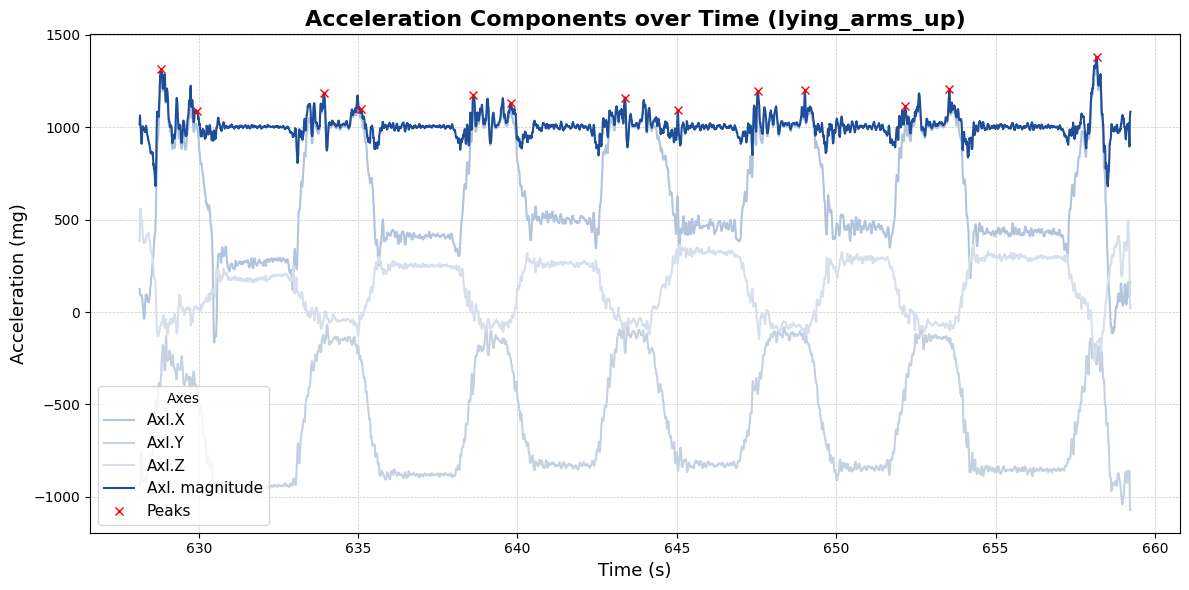

In [90]:
# we use the arm df from the previous cell
activity_label = 'lying_arms_up'
_, peaks, peaks_mask = plot_activity_accelerations_peaks_and_magnitude(df_filtered_rarm, activity_label, height=1065, distance=900)

In [ ]:
# investigate the peaks
peaks

In [91]:
# Manually alter the peaks such that the peaks can be used to differentiate between 
drop_peaks = []
filtered_peaks = []
filtered_peaks_original = []
for i in range(len(peaks_mask)):
    
    # if i == 2:
    #     filtered_peaks.append(peaks_mask[i] - 0.5*800)
    #     filtered_peaks_original.append(peaks[i] - 0.5*800)
    # if i == 3:
    #     filtered_peaks.append(peaks_mask[i] - 0.5*800)
    #     filtered_peaks_original.append(peaks[i] - 0.5*800)
        

    
    # if i == 0:
    #     filtered_peaks.append(peaks_mask[i] - 0.5*800)
    #     filtered_peaks_original.append(peaks[i]- 0.5*800)
    
    
    if i not in drop_peaks:
        filtered_peaks.append(peaks_mask[i])
        filtered_peaks_original.append(peaks[i])
        
    
    if i == 12:
        filtered_peaks.append(peaks_mask[i] + 1*800)
        filtered_peaks_original.append(peaks[i]+ 1*800)
        
        
    
    


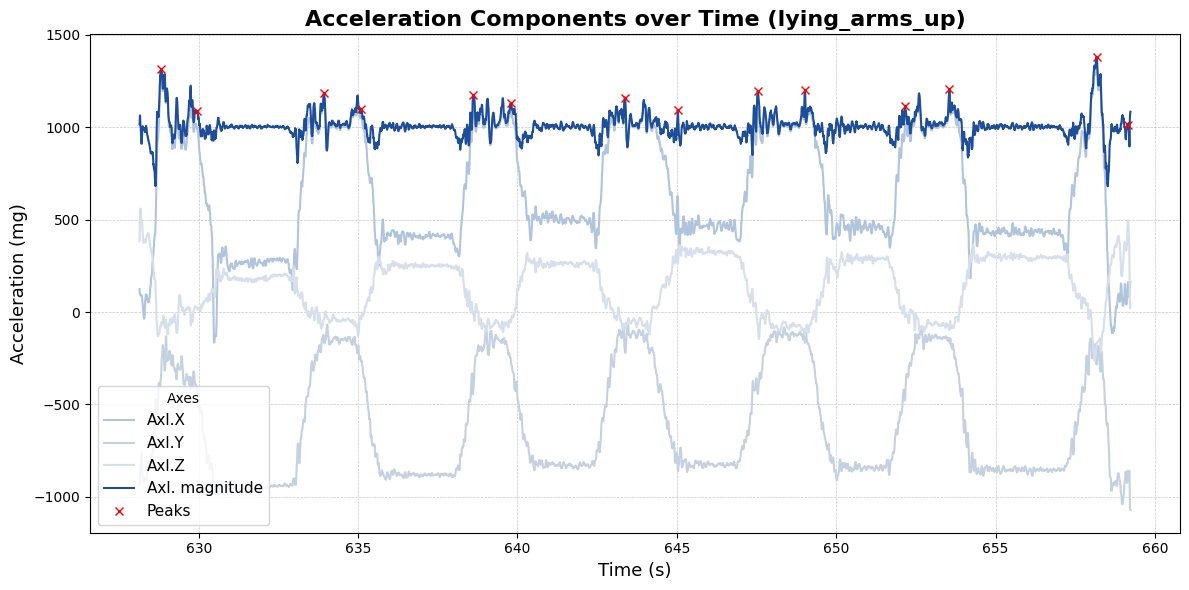

(            Timestamp   Gyr.X   Gyr.Y  Gyr.Z      Axl.X     Axl.Y       Axl.Z  \
 297521  1772025687864  11.830   2.415  0.350  124.44000  -934.032  382.592000   
 297522  1772025687865  12.040   1.890  0.665  122.48800  -934.032  395.768000   
 297523  1772025687866  12.145   1.120  0.700  114.19200  -934.032  408.456000   
 297524  1772025687867  12.285   0.350  0.980  113.70400  -934.032  421.144000   
 297525  1772025687869  12.320  -0.490  1.015  108.33600  -934.032  433.832000   
 ...               ...     ...     ...    ...        ...       ...         ...   
 322387  1772025718952 -12.600  22.120 -7.000  159.08800 -1072.136   20.008000   
 322388  1772025718953 -12.530  22.120 -6.580  161.04001 -1072.136   20.008000   
 322389  1772025718954 -12.075  22.120 -6.265  161.04001 -1072.136   27.328001   
 322390  1772025718956 -11.900  22.120 -5.635  161.04001 -1072.136   29.280000   
 322391  1772025718957 -11.725  22.120 -5.145  162.01600 -1072.136   39.040000   
 
             H

In [92]:
# plot again to see that everything aligns

plot_activity_accelerations_peaks_and_magnitude(df_filtered_rarm, activity_label, peak_indices=filtered_peaks)

In [86]:
len(filtered_peaks) == len(filtered_peaks_original)


True

In [93]:
# Split in the middle between last and first peak
even = []
odd = []
even_orig = []
odd_orig = []
for i in range(len(filtered_peaks)):
    if i % 2 == 0:
        # print(f'adding index {i} to EVEN')
        # print('second mark is', df_filtered_back['ReconstructedTime'].iloc[int(filtered_peaks_original[i])])
        even.append(filtered_peaks[i])
        even_orig.append(filtered_peaks_original[i])
    else:
        # print(f'adding index {i} to ODD')
        # print('second mark is', df_filtered_back['ReconstructedTime'].iloc[int(filtered_peaks_original[i])])
        odd.append(filtered_peaks[i])
        odd_orig.append(filtered_peaks_original[i])

# print(even_orig)
# print(odd_orig)
filtered_peaks_original = [] # clear the list
for i in range(len(odd_orig)):
    first = even_orig[i]
    second = odd_orig[i]
    # print(first,second)
    # print("In time")
    # print(df_filtered_back['ReconstructedTime'].iloc[int(first)], df_filtered_back['ReconstructedTime'].iloc[int(second)],)
   # print((first + second) // 2)
    # segment at middle point between even and odd peak, i.e. last of prev rep and first of next rep:
    
    filtered_peaks_original.append((first + second) // 2) 

print("Splits seconds marks")
for idx in filtered_peaks_original:
    print(df_filtered_lb['ReconstructedTime'].iloc[int(idx)])   
    
    

Splits seconds marks
629.39
634.51625
639.2025
644.2
648.2825
652.85875
658.66875


#### Save the repetitions start stop times to a .csv-file
Below, the df is also visualized. Check that the timestamps correspond with the plot above:)

In [94]:
print(filtered_peaks_original)
import importlib
import pre_processing.segment_repetition_vol2 as seg
importlib.reload(seg)
from pre_processing.segment_repetition_vol2 import get_start_stop_times_from_peaks

start_stop_reps_dict, start_stop_reps_df = start_stop_dict, intervals_df = get_start_stop_times_from_peaks(
    df=df_filtered_lb,
    peaks=filtered_peaks_original,
    activity_name=activity_label,
    num_reps=6,
    side_mode=None
)
start_stop_reps_df.to_csv(output_dir / f'start_stop_rep_times_{activity_label}.csv')


[np.int64(298517), np.int64(302618), np.int64(306367), np.int64(310365), np.int64(313631), np.int64(317292), np.int64(321940)]


In [95]:
# check that df makes sense
start_stop_reps_df

,rep_id,start_time,stop_time
0,lying_arms_up_1,629.39000,634.51625
1,lying_arms_up_2,634.51625,639.20250
2,lying_arms_up_3,639.20250,644.20000
3,lying_arms_up_4,644.20000,648.28250
4,lying_arms_up_5,648.28250,652.85875
5,lying_arms_up_6,652.85875,658.66875


#### Now, add a rep_id column to each sensor dataframe based on start stop time .csv files


In [96]:
# defien a dict with all dfs to assign rep_id for, they must have a corresponding .csv file with start_stop_times for the relevant activities. 
filtered_dfs = {
    "left_arm" : df_filtered_larm,
    "right_arm" : df_filtered_rarm,
    "upper_back" : df_filtered_ub,
    "lower_back" : df_filtered_lb,
    "left_sole" : df_filtered_lsole,
    "right_sole" : df_filtered_rsole
    }

# define a set of labels that if they occur, should not have rep_id assigned from a .csv, but rather from their label which is assumed to already be numbered after repetitions. 
numbered_labels = [
        "push",
        "pull",
        "drag",
        "stairs_up",
        "stairs_down"
]
# add a rep_id columm (just a copy of the labels to each df.)
for _, df in filtered_dfs.items():
    df["rep_id"] = df["label"].copy()
    
# run the next cell to assign rep_ids and save the final .csv files. 

In [97]:
import pre_processing.segment_repetition_vol2 as seg
import importlib
importlib.reload(seg)
from pre_processing.segment_repetition_vol2 import assign_rep_ids

assign_rep_ids(sensor_dfs=filtered_dfs, output_dir=output_dir, numbered_labels=numbered_labels)

Activities: ['forward_lean', 'sideways_lean', 'torso_twist', 'backward_lean', 'drag_1', 'drag_2', 'drag_3', 'drag_4', 'drag_5', 'arms_forward', 'shoulder_load', 'neutral_load_left', 'neutral_load_right', 'lying_arms_up', 'stairs_up_1', 'stairs_down_1', 'stairs_up_2', 'stairs_down_2', 'stairs_up_3', 'stairs_down_3', 'stairs_up_4', 'stairs_down_4', 'stairs_up_5', 'stairs_down_5']
✅ Assigned rep_ids for forward_lean
✅ Assigned rep_ids for sideways_lean
✅ Assigned rep_ids for torso_twist
✅ Assigned rep_ids for backward_lean
✅ Normalized numbered label 'drag_1' -> base label + rep_id preserved.
✅ Normalized numbered label 'drag_2' -> base label + rep_id preserved.
✅ Normalized numbered label 'drag_3' -> base label + rep_id preserved.
✅ Normalized numbered label 'drag_4' -> base label + rep_id preserved.
✅ Normalized numbered label 'drag_5' -> base label + rep_id preserved.
✅ Assigned rep_ids for arms_forward
✅ Assigned rep_ids for shoulder_load
✅ Assigned rep_ids for lying_arms_up
✅ Normali

{'left_arm':             Timestamp   Gyr.X    Gyr.Y   Gyr.Z      Axl.X       Axl.Y  \
 0       1583199581128   0.000    0.000   0.000    0.00000     0.00000   
 1       1583199581130   0.000  218.715   0.000    0.00000   854.48804   
 2       1583199581131   0.000  218.715   0.000    0.00000  1059.44800   
 3       1583199581132   0.000  218.715   0.000    0.00000  1059.44800   
 4       1583199581134 -58.415  218.715   0.000 -179.09601  1059.44800   
 ...               ...     ...      ...     ...        ...         ...   
 364925  1583200245726  25.970  -11.200 -11.235 -337.69600   855.95200   
 364926  1583200245727  25.690  -11.060  -9.590 -337.20800   851.07200   
 364927  1583200245729  25.515  -10.885   0.000    0.00000   401.62400   
 364928  1583200245730  25.095  -10.710   0.000    0.00000     0.00000   
 364929  1583200245731  24.885  -10.080   0.000    0.00000     0.00000   
 
             Axl.Z      Hdr.X      Hdr.Y       Hdr.Z  Mag.X  Mag.Y  Mag.Z  \
 0         0.00000  7

## Finished! 🎉
Go over output directory and delete unnecessary temp .csv files. DO NOT INGORE THIS STEP UNLESS YOU WANT TO DELETE THE SIMS OFF YOUR COMPUTER TO MAKE ROOM FOR DATA FILES (hint: you don't want that).


## What to do next? 💕
Add the correct paths to the get_paths.py - file (both individual test file paths and test folder path!). Then run pre_processing.clean_dataset_columns for the current test file. Requires  get_paths to be correct. after cleaning, add the _cleaned.csv suffix, i.e. the new path to get_paths. 

-----> Once all of the above has been completed, move on to **feature extraction**